#1. Import Required Libraries

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *

from sklearn.metrics import classification_report

# 2. Load Dataset

In [ ]:
train_dir = "/content/drive/MyDrive/Dataset/FruitinAmazon/train"

class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# 3. Check for Corrupted Images

In [ ]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


# Analyze Class Distribution

In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith(('.png','.jpg','.jpeg'))]

    class_counts[class_name] = len(images)

print("\nClass Distribution:")
for k,v in class_counts.items():
    print(k, ":", v)


Class Distribution:
acai : 15
cupuacu : 15
graviola : 15
guarana : 15
pupunha : 15
tucuma : 15


# 5. Visualize Sample Images

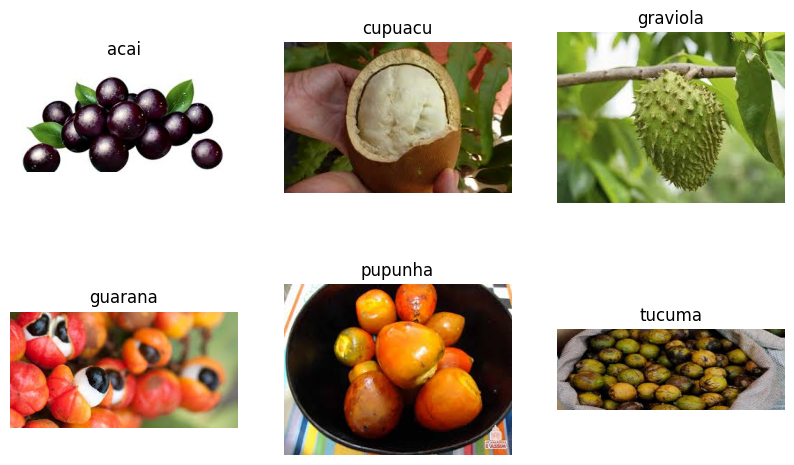

In [ ]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith(('.png','.jpg','.jpeg'))]

    img = random.choice(images)
    selected_images.append(os.path.join(class_path, img))
    selected_labels.append(class_name)

fig, axes = plt.subplots(2, 3, figsize=(10,6))

for i, ax in enumerate(axes.flat):
    if i < len(selected_images):
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")

plt.show()

# 6. Create Training and Validation Dataset

In [ ]:
image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


#7. Apply Data Augmentation

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.3),
])

# TASK 1: CNN MODEL (FROM SCRATCH)

# 8. Build CNN Model

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(224,224,3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

# 9. Compile and Train CNN Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.2778 - loss: 2.2904 - val_accuracy: 0.1667 - val_loss: 2.5397
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.4028 - loss: 1.5096 - val_accuracy: 0.0556 - val_loss: 2.0588
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6806 - loss: 1.0719 - val_accuracy: 0.2222 - val_loss: 1.8569
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6389 - loss: 0.9622 - val_accuracy: 0.2222 - val_loss: 1.8242
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6667 - loss: 0.7777 - val_accuracy: 0.2222 - val_loss: 1.9280
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6250 - loss: 0.8913 - val_accuracy: 0.2222 - val_loss: 2.0785
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6806 - loss: 0.9496 - val_accuracy: 0.0556 - val_loss: 2.2525
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.5417 - loss: 1.1023 - val_accuracy: 0.0556 - val_loss: 2.4285
Epoch 9/3

# 10. Plot Accuracy and Loss Graphs

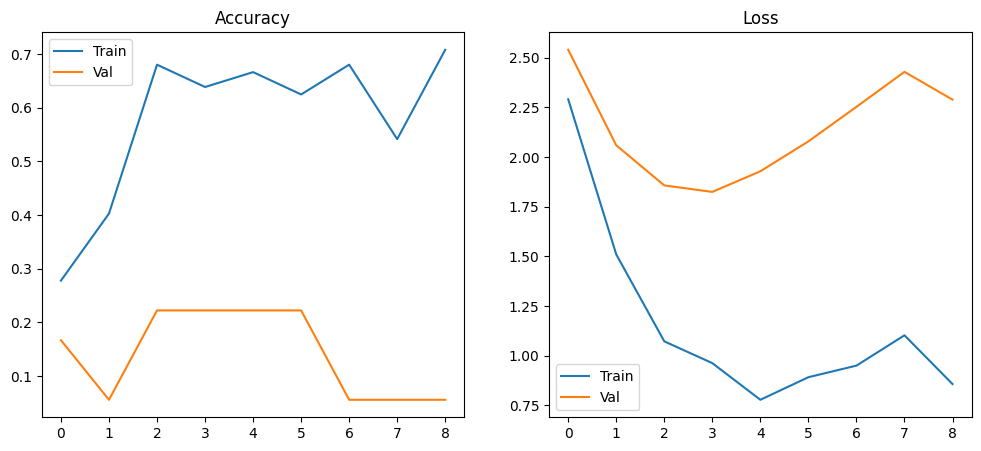

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.title("Loss")

plt.show()

# 11. Evaluate CNN Model

In [ ]:
loss, acc_cnn = model.evaluate(val_ds)
print("CNN Accuracy:", acc_cnn)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2222 - loss: 1.8242
CNN Accuracy: 0.2222222238779068


# 12. Classification Report

In [ ]:
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.22      1.00      0.36         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.22        18
   macro avg       0.04      0.17      0.06        18
weighted avg       0.05      0.22      0.08        18



# TASK 2: TRANSFER LEARNING USING VGG16
# 13. Load Pre-trained VGG16 Model

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# 14. Freeze Pre-trained Layers

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

# 15. Add Custom Classification Layers

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dense(len(class_names), activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=x)

# 16. Compile and Train VGG16 Model


In [ ]:
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 13s/step - accuracy: 0.2361 - loss: 6.7484 - val_accuracy: 0.3333 - val_loss: 6.8779
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 0.5972 - loss: 3.4132 - val_accuracy: 0.3889 - val_loss: 4.1998
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 0.9167 - loss: 0.3116 - val_accuracy: 0.4444 - val_loss: 4.0367
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 0.9583 - loss: 0.1188 - val_accuracy: 0.4444 - val_loss: 4.0956
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 0.9306 - loss: 0.1437 - val_accuracy: 0.4444 - val_loss: 4.1342
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 1.0000 - loss: 0.0234 - val_accuracy: 0.5556 - val_loss: 3.9222
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.5556 - val_loss: 3.7783
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.5556 - val_loss: 3.7233


# 17. Evaluate VGG16 Model

In [ ]:
loss, acc_vgg = vgg_model.evaluate(val_ds)
print("VGG16 Accuracy:", acc_vgg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.6111 - loss: 3.6927
VGG16 Accuracy: 0.6111111044883728


In [ ]:
for images, labels in val_ds.take(1):
    preds = vgg_model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    print("Predicted:", pred_labels[:5])
    print("Actual   :", labels[:5].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Predicted: [4 2 1 5 2]
Actual   : [4 4 1 5 1]


# 18. Final Comparison

In [ ]:
print("\nFinal Comparison:")
print("CNN Accuracy :", acc_cnn)
print("VGG16 Accuracy :", acc_vgg)


Final Comparison:
CNN Accuracy : 0.2222222238779068
VGG16 Accuracy : 0.6111111044883728


## Conclusion
In this experiment, a Convolutional Neural Network (CNN) was built from the ground up to classify fruit images. However, its performance remained limited, mainly due to the small size of the dataset and the imbalance among classes, which reduced its ability to generalize effectively.

To address these limitations, transfer learning was introduced using the VGG16 model that had already been trained on the ImageNet dataset. By keeping the convolutional layers fixed and only training the newly added output layers, the model was able to make use of previously learned visual features.

As a result, the VGG16-based model performed noticeably better than the custom CNN, achieving improved accuracy and more reliable classification outcomes. This highlights the advantage of transfer learning, particularly when dealing with limited data.

In conclusion, the experiment indicates that pre-trained architectures like VGG16 are more efficient and provide stronger generalization than training a CNN from scratch in situations with constrained datasets.